In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/Telco_Customer_Churn.csv")

In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [6]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [7]:
df_clean=df.drop("customerID",axis=1)

In [9]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [10]:
df_clean.sample(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6121,Female,0,Yes,Yes,8,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.50,159.35,No
5715,Male,0,No,No,32,Yes,Yes,Fiber optic,Yes,Yes,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),108.15,3432.9,Yes
2438,Female,0,No,No,8,Yes,Yes,Fiber optic,Yes,No,No,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.35,847.3,Yes
1755,Female,0,No,No,12,Yes,No,DSL,No,Yes,No,Yes,No,No,Month-to-month,Yes,Electronic check,54.30,654.5,No
2538,Male,0,Yes,Yes,34,No,No phone service,DSL,No,No,No,Yes,Yes,No,Two year,Yes,Electronic check,40.55,1325.85,No
2977,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,19.50,19.5,No
5698,Male,0,Yes,Yes,21,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,104.40,2157.95,Yes
5581,Male,0,Yes,Yes,68,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,113.15,7856,Yes
2362,Male,0,Yes,Yes,49,No,No phone service,DSL,Yes,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,39.20,1838.15,No
2141,Male,0,Yes,Yes,16,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Electronic check,20.15,341.35,No


<Axes: xlabel='Churn', ylabel='count'>

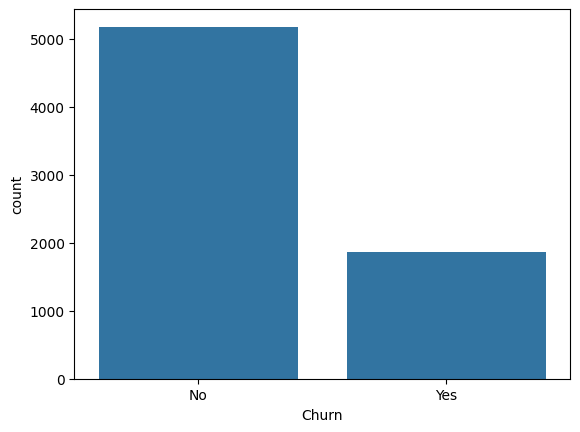

In [12]:
sns.countplot(x="Churn", data=df_clean)

<Axes: xlabel='gender', ylabel='count'>

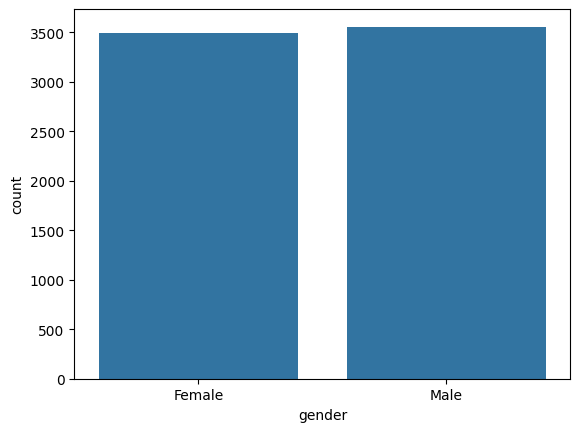

In [13]:
sns.countplot(x="gender", data=df_clean)

array([[<Axes: title={'center': 'SeniorCitizen'}>,
        <Axes: title={'center': 'tenure'}>],
       [<Axes: title={'center': 'MonthlyCharges'}>, <Axes: >]],
      dtype=object)

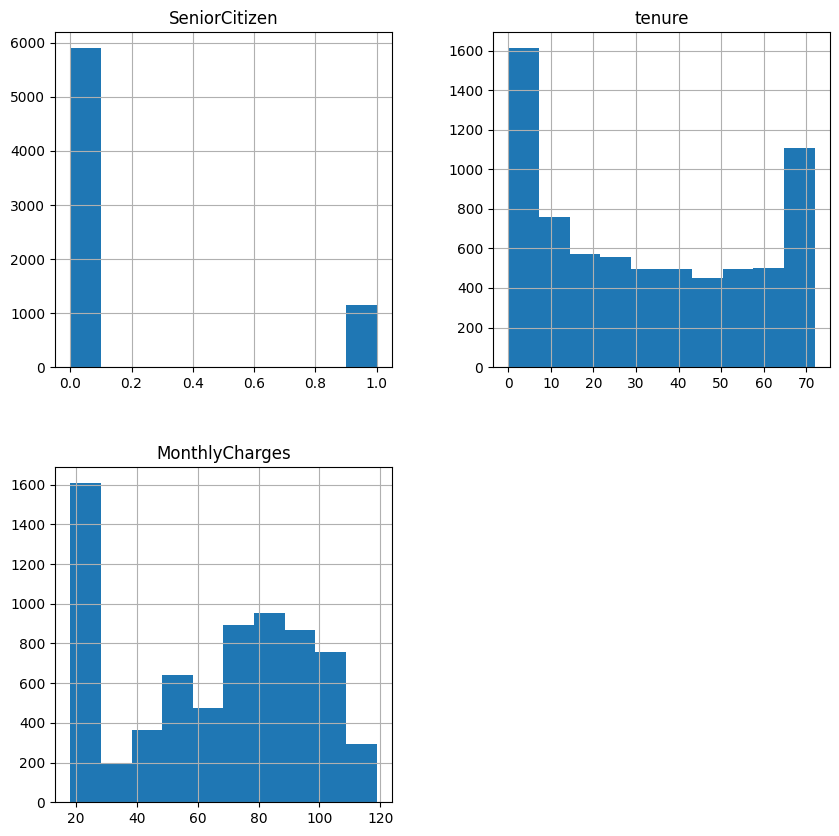

In [14]:
df_clean.hist(figsize=(10,10))

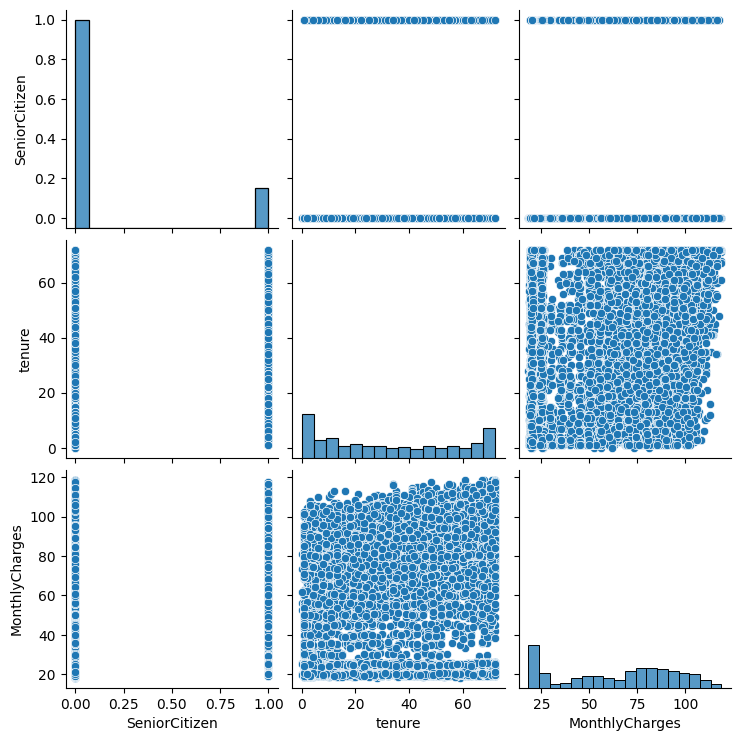

In [16]:
sns.pairplot(data=df_clean)

In [17]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [21]:
df_clean.sample(20)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5905,Male,0,No,No,1,Yes,No,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.00,85,No
4835,Male,0,Yes,No,65,Yes,Yes,Fiber optic,Yes,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,104.25,6812.95,No
4461,Male,0,No,No,29,Yes,No,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,94.20,2607.6,No
2719,Female,1,Yes,Yes,56,Yes,No,DSL,Yes,No,No,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),72.60,4084.35,No
4182,Female,1,No,No,29,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,No,Electronic check,98.65,2862.75,Yes
5328,Female,0,Yes,No,55,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,One year,Yes,Credit card (automatic),66.05,3462.1,No
4962,Female,0,Yes,Yes,17,Yes,No,DSL,Yes,Yes,No,No,Yes,Yes,Month-to-month,No,Mailed check,74.55,1215.8,No
4485,Male,0,Yes,No,66,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.70,6075.9,No
5557,Female,0,No,No,5,Yes,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,No,Electronic check,80.20,384.25,No
6172,Male,0,Yes,No,10,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,659.65,Yes


In [30]:
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
median_totalcharges = df_clean['TotalCharges'].median()
df_clean['TotalCharges'].fillna(median_totalcharges, inplace=True)
median_loanamount=df_clean["TotalCharges"].median()
median_loanamount

/tmp/ipykernel_625/3098653322.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['TotalCharges'].fillna(median_totalcharges, inplace=True)


1397.475

In [31]:
df_clean.sample(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2154,0,0,0,1,24,1,0,2,1,1,1,1,1,1,2,0,3,19.75,498.100,0
4149,1,0,1,0,71,0,1,0,0,2,0,0,2,2,2,0,2,49.35,3515.250,1
1048,1,0,0,0,29,1,0,2,1,1,1,1,1,1,1,1,3,19.80,572.200,0
2328,0,1,1,0,35,1,2,1,0,0,2,0,2,2,0,0,0,102.05,3452.550,0
1643,1,0,1,0,37,1,0,1,0,0,2,2,0,2,0,1,2,90.35,3419.300,0
13,1,0,0,0,49,1,2,1,0,2,2,0,2,2,0,1,0,103.70,5036.300,1
1389,0,1,1,0,34,1,2,1,0,2,2,0,0,2,0,1,2,94.25,3217.550,1
753,1,0,0,1,0,1,0,2,1,1,1,1,1,1,2,0,3,20.25,1397.475,0
3271,1,1,1,0,12,1,2,1,0,2,0,0,2,2,0,1,2,101.35,1218.550,1
1266,0,1,0,0,4,1,2,1,2,0,0,0,0,0,0,1,2,80.25,303.700,0


In [32]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
cat_cols=["gender","Partner","Dependents","PhoneService","MultipleLines","InternetService","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies","Contract","PaperlessBilling","PaymentMethod","Churn"]
for col in cat_cols:
  df_clean[col]=le.fit_transform(df_clean[col])

In [33]:
df_clean.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6670,0,0,1,1,0,1,2,0,0,2,2,2,2,0,2,0,3,73.35,1397.475,0
1194,0,0,0,0,14,1,0,0,0,2,0,0,0,0,0,0,2,50.45,765.450,0
4791,1,0,1,0,3,1,0,2,1,1,1,1,1,1,0,0,0,20.00,49.650,0
1131,0,0,1,0,14,1,2,0,2,0,0,0,2,0,0,1,0,64.70,941.000,1
5580,1,0,0,0,48,1,0,2,1,1,1,1,1,1,1,0,0,19.95,1004.500,0


In [41]:
from sklearn.model_selection import train_test_split
#df=pd.read_csv("/content/Telco_Customer_Churn.csv")
df_clean.head()
Y=df_clean["Churn"]
X=df_clean.drop(["Churn"],axis=1)
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3)
df = df_clean

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model_lr=LogisticRegression()
model_lr.fit(X_train,Y_train)
print(model_lr.score(X_train,Y_train))
print(model_lr.score(X_test,Y_test))

# 1. Get model predictions
y_train_pred = model_lr.predict(X_train)
y_test_pred = model_lr.predict(X_test)

# 2. Get raw counts of correct predictions
correct_train = accuracy_score(Y_train, y_train_pred, normalize=False)
correct_test = accuracy_score(Y_test, y_test_pred, normalize=False)

print(f"Train Correct: {correct_train} out of {len(Y_train)}")
print(f"Test Correct:  {correct_test} out of {len(Y_test)}")

0.8081135902636917
0.7827733080927591
Train Correct: 3984.0 out of 4930
Test Correct:  1654.0 out of 2113


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [43]:
from sklearn.svm import SVC
model_lr=SVC()
model_lr.fit(X_train,Y_train)
print(model_lr.score(X_train,Y_train))
print(model_lr.score(X_test,Y_test))
from sklearn.metrics import accuracy_score

# 1. Get model predictions
y_train_pred = model_lr.predict(X_train)
y_test_pred = model_lr.predict(X_test)

# 2. Get raw counts of correct predictions
correct_train = accuracy_score(Y_train, y_train_pred, normalize=False)
correct_test = accuracy_score(Y_test, y_test_pred, normalize=False)

print(f"Train Correct: {correct_train} out of {len(Y_train)}")
print(f"Test Correct:  {correct_test} out of {len(Y_test)}")

0.7440162271805274
0.7127307146237577
Train Correct: 3668.0 out of 4930
Test Correct:  1506.0 out of 2113


In [37]:
from sklearn.tree import DecisionTreeClassifier
model_lr=DecisionTreeClassifier()
model_lr.fit(X_train,Y_train)
print(model_lr.score(X_train,Y_train))
print(model_lr.score(X_test,Y_test))

0.9979716024340771
0.7155702792238523


In [38]:
df_clean.describe(include='all')

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.504756,0.162147,0.483033,0.299588,32.371149,0.903166,0.940508,0.872923,0.790004,0.906432,0.904444,0.797104,0.985376,0.992475,0.690473,0.592219,1.574329,64.761692,2281.916928,0.265370
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.948554,0.737796,0.859848,0.880162,0.879949,0.861551,0.885002,0.885091,0.833755,0.491457,1.068104,30.090047,2265.270398,0.441561
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,35.500000,402.225000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,2.000000,70.350000,1397.475000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,89.850000,3786.600000,1.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,118.750000,8684.800000,1.000000


In [49]:
!pip install -q gradio

In [ ]:
import gradio as gr
import numpy as np

def predict_churn(*args):
    # Prepare the input for the model
    input_array = np.array(args).reshape(1, -1)
    prediction = model_lr.predict(input_array)[0]

    # Try to get probability if the model supports it
    try:
        prob = model_lr.predict_proba(input_array)[0][1]
        return f"Prediction: {'Churn' if prediction == 1 else 'No Churn'} (Confidence: {prob:.2f})"
    except:
        return "Prediction: Churn" if prediction == 1 else "Prediction: No Churn"

# Create dynamic inputs based on the training features (X)
inputs = []
for col in X.columns:
    unique_vals = sorted(df[col].unique())
    # If small number of unique values, assume categorical encoding and use dropdown
    if len(unique_vals) <= 5:
        inputs.append(gr.Dropdown(choices=unique_vals, label=col, value=unique_vals[0]))
    else:
        # Otherwise use a number input with the median as default
        inputs.append(gr.Number(label=col, value=float(df[col].median())))

demo = gr.Interface(
    fn=predict_churn,
    inputs=inputs,
    outputs="text",
    title="Telco Churn Prediction App",
    description="Input the numerical feature values to see if the customer is likely to churn."
)

demo.launch(debug=True)

ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 422, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 63, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1163, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 90, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).



ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 422, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 63, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1163, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 90, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://9d40e82d4282a975ee.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Streaming output truncated to the last 5000 lines.
  File "/usr/lib/python3.12/json/__init__.py", line 238, in dumps
    **kw).encode(obj)
          ^^^^^^^^^^^
  File "/usr/lib/python3.12/json/encoder.py", line 202, in encode
    chunks = list(chunks)
             ^^^^^^^^^^^^
  File "/usr/lib/python3.12/json/encoder.py", line 432, in _iterencode
    yield from _iterencode_dict(o, _current_indent_level)
  File "/usr/lib/python3.12/json/encoder.py", line 406, in _iterencode_dict
    yield from chunks
  File "/usr/lib/python3.12/json/encoder.py", line 439, in _iterencode
    o = _default(o)
        ^^^^^^^^^^^
  File "/usr/lib/python3.12/json/encoder.py", line 180, in default
    raise TypeError(f'Object of type {o.__class__.__name__} '
TypeError: Object of type int64 is not JSON serializable
ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 422, in run_asgi
    resul